# MFRC EDA

MFRC differs from the benchmark-style datasets because it contains natural Reddit discourse rather than authored moral scenarios. This notebook shows the raw annotation structure, then checks why the processed version is still not yet ready for ordinary supervised training in the current pipeline.


In [1]:
from __future__ import annotations

from ast import literal_eval
from collections import Counter
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def set_csv_field_limit() -> None:
    limit = sys.maxsize
    while True:
        try:
            csv.field_size_limit(limit)
            return
        except OverflowError:
            limit //= 10


set_csv_field_limit()
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 160)


def find_project_root() -> tuple[Path, Path]:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        for data_name in ("Data", "data"):
            data_root = candidate / data_name
            if data_root.exists():
                return candidate, data_root
    raise FileNotFoundError("Could not find project data directory.")


ROOT, DATA_ROOT = find_project_root()
RAW_PATH = DATA_ROOT / "raw/mfrc/train.parquet"
PROCESSED_PATH = DATA_ROOT / "processed/mfrc/mfrc.csv"

print("Notebook:", "MFRC EDA")
print("Project root:", ROOT)
print("Raw path:", RAW_PATH)
print("Processed path:", PROCESSED_PATH)


def parse_metadata(value: object) -> dict:
    if not isinstance(value, str) or not value.strip():
        return {}
    try:
        return json.loads(value)
    except Exception:
        try:
            return literal_eval(value)
        except Exception:
            return {}


def preview_frame(df: pd.DataFrame, n: int = 5) -> None:
    display(df.head(n))


def count_chars(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.len()


def markdown(text: str) -> None:
    display(Markdown(text))


Notebook: MFRC EDA
Project root: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
Raw path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\raw\mfrc\train.parquet
Processed path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\processed\mfrc\mfrc.csv


In [2]:
raw_df = pd.read_parquet(RAW_PATH)
markdown("### Raw Snapshot")
display(pd.DataFrame({
    "rows": [len(raw_df)],
    "columns": [len(raw_df.columns)],
    "subreddits": [raw_df["subreddit"].nunique() if "subreddit" in raw_df.columns else None],
    "annotations": [raw_df["annotation"].nunique() if "annotation" in raw_df.columns else None],
}))
preview_frame(raw_df)


### Raw Snapshot

,rows,columns,subreddits,annotations
0,61226,6,11,128


,text,subreddit,bucket,annotator,annotation,confidence
0,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,europe,French politics,annotator03,Non-Moral,Confident
1,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,europe,French politics,annotator01,Purity,Confident
2,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,europe,French politics,annotator02,Thin Morality,Confident
3,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapoteau"" or ""compost"", crosspost is ""croixpo...",europe,French politics,annotator03,Non-Moral,Confident
4,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapoteau"" or ""compost"", crosspost is ""croixpo...",europe,French politics,annotator00,Non-Moral,Somewhat Confident


In [3]:
example_cols = [c for c in ["text", "subreddit", "bucket", "annotator", "annotation", "confidence"] if c in raw_df.columns]
markdown("### Representative Raw Reddit Examples")
display(raw_df[example_cols].head(8))


### Representative Raw Reddit Examples

,text,subreddit,bucket,annotator,annotation,confidence
0,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,europe,French politics,annotator03,Non-Moral,Confident
1,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,europe,French politics,annotator01,Purity,Confident
2,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,europe,French politics,annotator02,Thin Morality,Confident
3,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapoteau"" or ""compost"", crosspost is ""croixpo...",europe,French politics,annotator03,Non-Moral,Confident
4,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapoteau"" or ""compost"", crosspost is ""croixpo...",europe,French politics,annotator00,Non-Moral,Somewhat Confident
5,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapoteau"" or ""compost"", crosspost is ""croixpo...",europe,French politics,annotator02,Non-Moral,Confident
6,TBH Marion Le Pen would be better. Closet fascist vs flamboyant extroverted fascist.,neoliberal,French politics,annotator03,Non-Moral,Somewhat Confident
7,TBH Marion Le Pen would be better. Closet fascist vs flamboyant extroverted fascist.,neoliberal,French politics,annotator00,Thin Morality,Not Confident


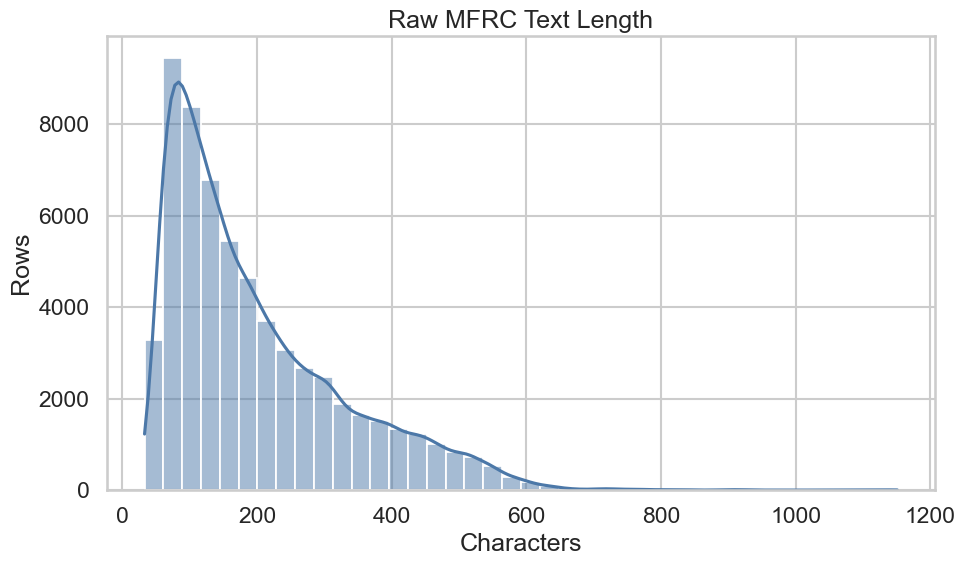

In [4]:
raw_df["char_len"] = count_chars(raw_df["text"])
plt.figure(figsize=(10, 6))
sns.histplot(raw_df["char_len"], bins=40, kde=True, color="#4C78A8")
plt.title("Raw MFRC Text Length")
plt.xlabel("Characters")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


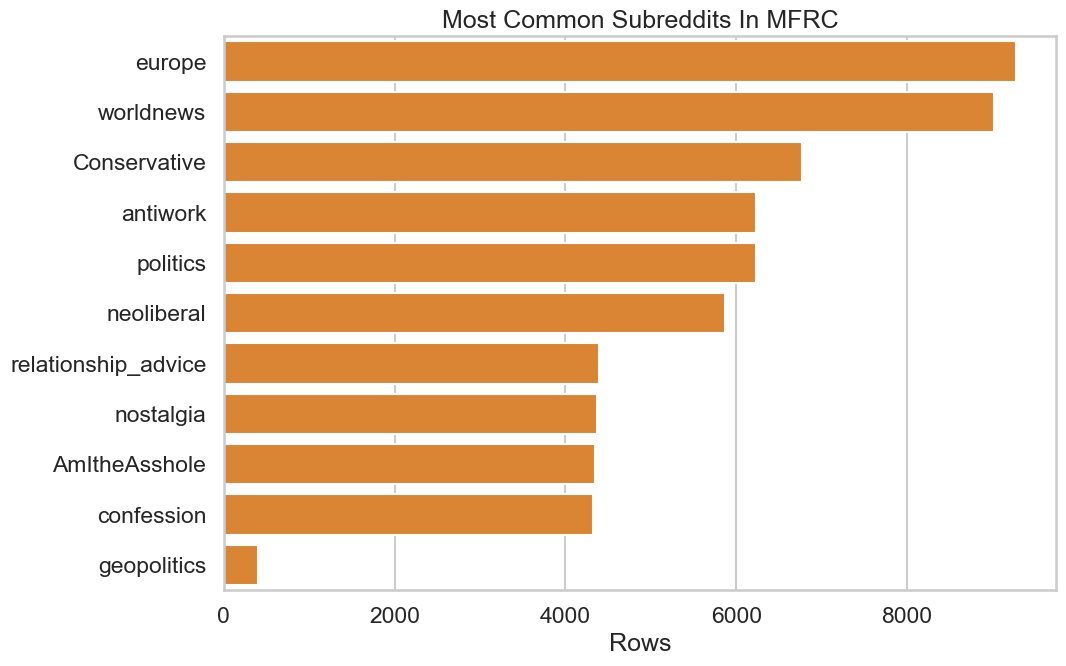

In [5]:
top_subreddits = raw_df["subreddit"].fillna("unknown").value_counts().head(12).rename_axis("subreddit").reset_index(name="count")
plt.figure(figsize=(11, 7))
sns.barplot(data=top_subreddits, x="count", y="subreddit", color="#F58518")
plt.title("Most Common Subreddits In MFRC")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


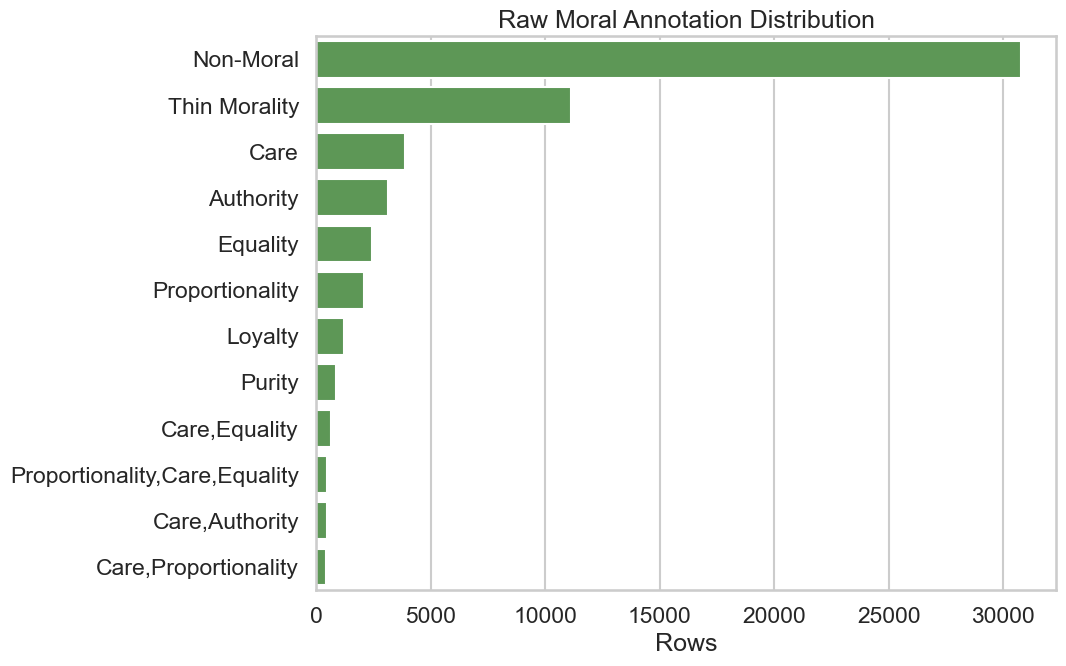

In [6]:
annotation_counts = raw_df["annotation"].fillna("unknown").value_counts().head(12).rename_axis("annotation").reset_index(name="count")
plt.figure(figsize=(11, 7))
sns.barplot(data=annotation_counts, x="count", y="annotation", color="#54A24B")
plt.title("Raw Moral Annotation Distribution")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


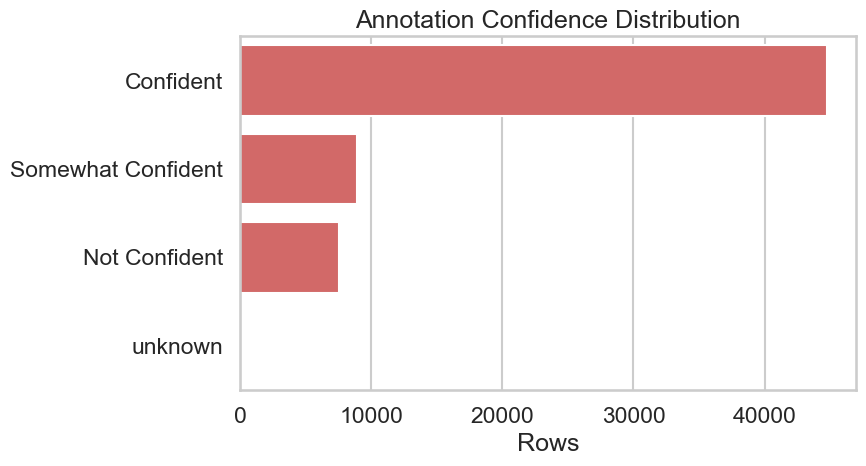

In [7]:
if "confidence" in raw_df.columns:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=raw_df, y="confidence", order=raw_df["confidence"].fillna("unknown").value_counts().index, color="#E45756")
    plt.title("Annotation Confidence Distribution")
    plt.xlabel("Rows")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


In [8]:
repeat_examples = (
    raw_df.groupby("text")
    .size()
    .reset_index(name="annotation_count")
    .query("annotation_count > 1")
    .sort_values("annotation_count", ascending=False)
)
markdown("### Multi-Annotated Comments")
display(repeat_examples.head(5))
if not repeat_examples.empty:
    sample_text = repeat_examples.iloc[0]["text"]
    display(raw_df.loc[raw_df["text"] == sample_text, [c for c in ["text", "annotation", "annotator", "confidence"] if c in raw_df.columns]].head(10))


### Multi-Annotated Comments

,text,annotation_count
17804,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,11
11862,She's the worst kind. Socially racist ([calls for a complete ban on immigration bc brown people scary](http://www.independent.co.uk/news/world/europe/french...,8
2982,Congratulations to Marine Le Pen on managing to come in third in a race with two contestants.,7
13299,The question in all of this is in what shape will the FN be in by 2022. I don't think it's a guarantee that Marine Le Pen or someone else connected to the F...,6
8678,"Keep shaming neoliberal voters like this, this is the kind of attitude that led to Macron winning.",6


,text,annotation,annotator,confidence
1598,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator03,Confident
1599,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator02,Confident
7635,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator03,Confident
14951,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Loyalty,annotator04,Confident
14952,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator01,Confident
14953,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator02,Confident
19220,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator01,Confident
19221,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator00,Confident
52841,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator03,Confident
54315,༼ つ ◕_◕ ༽つ MACRON TAKE MY ENERGY ༼ つ ◕_◕ ༽つ,Non-Moral,annotator01,Confident


In [9]:
processed_df = pd.read_csv(PROCESSED_PATH)
processed_df["metadata_parsed"] = processed_df["metadata"].map(parse_metadata)
processed_df["annotation"] = processed_df["metadata_parsed"].map(lambda meta: meta.get("labels", {}).get("annotation", ""))

markdown("### Processed Snapshot")
display(pd.DataFrame({
    "processed_rows": [len(processed_df)],
    "nonempty_text_rows": [int(processed_df["text"].fillna("").astype(str).str.strip().ne("").sum())],
    "nonempty_label_rows": [int(processed_df["label"].fillna("").astype(str).str.strip().ne("").sum())],
    "annotation_values_in_metadata": [int(processed_df["annotation"].astype(str).str.strip().ne("").sum())],
}))
display(processed_df[["text", "label", "task", "split", "annotation"]].head(8))


### Processed Snapshot

,processed_rows,nonempty_text_rows,nonempty_label_rows,annotation_values_in_metadata
0,61226,61226,0,61226


,text,label,task,split,annotation
0,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,NaN,moral_sentiment_multilabel,train,Non-Moral
1,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,NaN,moral_sentiment_multilabel,train,Purity
2,That particular part of the debate is especially funny. Macron was explaining he did not think FN voters were evil and that from where he comes from he knew...,NaN,moral_sentiment_multilabel,train,Thin Morality
3,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapoteau"" or ""compost"", crosspost is ""croixpo...",NaN,moral_sentiment_multilabel,train,Non-Moral
4,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapoteau"" or ""compost"", crosspost is ""croixpo...",NaN,moral_sentiment_multilabel,train,Non-Moral
5,"/r/france is pretty lively, with it's own lingo that is usually deliberately bad translations - shitpost is ""cacapoteau"" or ""compost"", crosspost is ""croixpo...",NaN,moral_sentiment_multilabel,train,Non-Moral
6,TBH Marion Le Pen would be better. Closet fascist vs flamboyant extroverted fascist.,NaN,moral_sentiment_multilabel,train,Non-Moral
7,TBH Marion Le Pen would be better. Closet fascist vs flamboyant extroverted fascist.,NaN,moral_sentiment_multilabel,train,Thin Morality


In [10]:
comparison_df = pd.DataFrame([
    {"stage": "raw", "rows": len(raw_df), "ready_for_flat_supervised_training": "no", "reason": "multiple annotations / rich metadata"},
    {"stage": "processed", "rows": len(processed_df), "ready_for_flat_supervised_training": "no", "reason": "label column is blank; annotations remain nested"},
])
markdown("### Raw vs Processed Comparison")
display(comparison_df)


### Raw vs Processed Comparison

,stage,rows,ready_for_flat_supervised_training,reason
0,raw,61226,no,multiple annotations / rich metadata
1,processed,61226,no,label column is blank; annotations remain nested


## Key Takeaways

- MFRC contains natural social media language, so the text is noisier and more realistic than benchmark-style ethics prompts.
- The dataset is annotation-rich, but the annotations are not yet collapsed into one clean supervised label in the current pipeline.
- This makes MFRC valuable for future multi-label or annotator-aware work, but not yet a direct plug-in replacement for ETHICS or NormBank.
